In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the Data

df = pd.read_excel(r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\data\Loan Information_Data.xlsx")

In [3]:
df.head()

,REF,LENDERNAME,ORDERSOURCE,Name,Organisation_Name,Phone,State Name,Address,Date,LOANDATE,...,LOANTYPE,Agent Name,Agent Status,TeamLead,ACM,RCM,Market Name,__First_repayment_date,__Last_repayment_date,ACCRUALSTATUS
0,0ehu7bhxb,OmniPay Limited,Distributor App,Hannah Amiesimaka,VHANESKA NIG ENTERPRISES,08033398479,Rivers,"118, Bende street, Borokiri, Town, Port Harcou...",2026-09-08,2026-09-08 00:59:38,...,multiproNew,Victoria Godspower,Status Quo,Bright Ezenwa Agoha,Rohit,Rahul,Town,NaT,NaT,active
1,6vgh6l8ki,OmniPay Limited,NaN,ONU CHRISTIAN EMEKA,ONU CHRISTIAN EMEKA,08030763935,Abuja Fed. Capital,"772, behind KP plaza Kapwa FLT 8 lugbe , Abuja",2026-09-08,2026-09-08 00:49:22,...,paylaterPlus,James Ada Destiny,Hunter,Olorunfemi Temidayo,Raja,NaN,Gwagwalada,NaT,NaT,active
2,16azbpz86,OmniPay Limited,NaN,Omidiora Ebenezer S,Omidiora Ebenezer S,08032082889,Lagos,2 onabadejo cls ipaja,2026-09-08,2026-09-08 00:47:41,...,paylaterPlus,Olapade Quadri Segun,Status Quo,Ogungbola Abdulwasiu Abdulazeez,Vaibhav,NaN,Agric market,NaT,NaT,active
3,2aiditrq4,OmniPay Limited,NaN,Ndubisi Robinson,Ndubisi Robinson,08069793488,Lagos,"15/12, JOHN OGUN MUYIWA STREET OFF SHOSANYA IJ...",2026-09-08,2026-09-08 00:46:20,...,paylaterPlus,Sunday Kayode,NaN,Olagunju Olanrewaju,Ayotunde,NaN,Ikotun Market 2,NaT,NaT,active
4,czr1eb245,OmniPay Limited,NaN,Okpara christopher onyegbule,Okpara christopher onyegbule,08020556167,Lagos,33b Alebiosun Street ijegun satellite ojo,2026-09-08,2026-09-08 00:28:57,...,paylaterPlus,Egejuru Chiamaka Favour,Farmer,Udofia Wisdom,Tolu,Sushant,TRADEFAIR MARKET B,NaT,NaT,active


In [4]:
df.shape

(101343, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101343 entries, 0 to 101342
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   REF                     101342 non-null  object        
 1   LENDERNAME              101340 non-null  object        
 2   ORDERSOURCE             101328 non-null  object        
 3   Name                    101332 non-null  object        
 4   Organisation_Name       99021 non-null   object        
 5   Phone                   101332 non-null  object        
 6   State Name              101028 non-null  object        
 7   Address                 101028 non-null  object        
 8   Date                    101340 non-null  datetime64[ns]
 9   LOANDATE                101340 non-null  datetime64[ns]
 10  LOANID                  101340 non-null  object        
 11  ORDERID                 101340 non-null  object        
 12  LOANAMOUNT              101341

In [6]:
df.describe(include="all")

,REF,LENDERNAME,ORDERSOURCE,Name,Organisation_Name,Phone,State Name,Address,Date,LOANDATE,...,LOANTYPE,Agent Name,Agent Status,TeamLead,ACM,RCM,Market Name,__First_repayment_date,__Last_repayment_date,ACCRUALSTATUS
count,101342,101340,101328,101332,99021,101332,101028,101028,101340,101340,...,101340,90029,66295,78813,90029,39622,78232,98526,98526,99174
unique,2961,7,9,2900,2886,2805,32,2931,NaN,NaN,...,7,151,5,41,14,3,158,NaN,NaN,2
top,wj2iolkp0,OmniPay Limited,Distributor App,MACDEN COMMUNICATIONS LIMITED,MACDEN COMMUNICATIONS LIMITED,"08062690098,07037394669",Lagos,"No 4’ Wempco road, ogba ikeja",NaN,NaN,...,bnpl,Downgraded,Farmer,Adewale Adeyemi,Ayotunde,Rahul,TRADEFAIR MARKET A,NaN,NaN,active
freq,826,59388,48691,826,826,826,43797,826,NaN,NaN,...,67663,11042,30609,6847,12536,18244,2266,NaN,NaN,98953
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-21 10:56:01.705150976,2025-08-22 00:27:07.237142272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-28 02:18:33.621115136,2025-09-01 11:26:08.080283392,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-21 00:00:00,2023-06-21 13:34:28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-26 13:01:04,2023-06-26 13:01:04,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-06 00:00:00,2025-02-06 21:27:40.750000128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-18 15:53:09,2025-02-22 22:43:30.249999872,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-29 00:00:00,2025-09-29 07:10:02.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-04 19:49:59.500000,2025-10-09 12:24:13.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-11 00:00:00,2026-04-11 14:20:42.249999872,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-15 19:57:59.249999872,2026-04-21 07:32:56.750000128,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08 00:00:00,2026-09-08 00:59:38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08 01:04:48,2026-09-08 01:05:19,NaN


In [7]:
df.columns.tolist()

['REF',
 'LENDERNAME',
 'ORDERSOURCE',
 'Name',
 'Organisation_Name',
 'Phone',
 'State Name',
 'Address',
 'Date',
 'LOANDATE',
 'LOANID',
 'ORDERID',
 'LOANAMOUNT',
 'Total Amount Recovered',
 'Total Amount Pending',
 'Loan Aging',
 'Loan Aging Bucket',
 'Loan Status',
 'Loan Class',
 'Total Interest Accrued',
 'Total Interest Charged',
 'Management Fee',
 'Tax',
 'LOANTYPE',
 'Agent Name',
 'Agent Status',
 'TeamLead',
 'ACM',
 'RCM',
 'Market Name',
 '__First_repayment_date',
 '__Last_repayment_date',
 'ACCRUALSTATUS']

In [8]:
df.columns.tolist()

['REF',
 'LENDERNAME',
 'ORDERSOURCE',
 'Name',
 'Organisation_Name',
 'Phone',
 'State Name',
 'Address',
 'Date',
 'LOANDATE',
 'LOANID',
 'ORDERID',
 'LOANAMOUNT',
 'Total Amount Recovered',
 'Total Amount Pending',
 'Loan Aging',
 'Loan Aging Bucket',
 'Loan Status',
 'Loan Class',
 'Total Interest Accrued',
 'Total Interest Charged',
 'Management Fee',
 'Tax',
 'LOANTYPE',
 'Agent Name',
 'Agent Status',
 'TeamLead',
 'ACM',
 'RCM',
 'Market Name',
 '__First_repayment_date',
 '__Last_repayment_date',
 'ACCRUALSTATUS']

In [9]:
df["Loan Class"].value_counts()

Loan Class
Fully Recovered    97358
Bad Loan            1987
Active              1912
NP Loan               83
Name: count, dtype: int64

In [10]:
df["NPL"] = df["Loan Class"].isin(
    ["Bad Loan", "NP Loan"]
).astype(int)

In [11]:
df["NPL"].value_counts()

NPL
0    99273
1     2070
Name: count, dtype: int64

In [12]:
id_columns = [
    "REF",
    "Name",
    "Phone",
    "Address",
    "LOANID",
    "ORDERID"
]

In [13]:
leakage_columns = [
    "Loan Class",
    "Loan Status",
    "Loan Aging",
    "Loan Aging Bucket",
    "Total Amount Recovered",
    "Total Amount Pending",
    "__Last_repayment_date",
    "__First_repayment_date",
    "ACCRUALSTATUS"
]

In [14]:
features_to_drop = id_columns + leakage_columns

X = df.drop(
    columns=features_to_drop + ["NPL"],
    errors="ignore"
)

y = df["NPL"]

In [15]:
X.shape

(101343, 18)

In [16]:
X.columns.tolist()

['LENDERNAME',
 'ORDERSOURCE',
 'Organisation_Name',
 'State Name',
 'Date',
 'LOANDATE',
 'LOANAMOUNT',
 'Total Interest Accrued',
 'Total Interest Charged',
 'Management Fee',
 'Tax',
 'LOANTYPE',
 'Agent Name',
 'Agent Status',
 'TeamLead',
 'ACM',
 'RCM',
 'Market Name']

In [17]:
df["Interest_Rate"] = (
    df["Total Interest Charged"] /
    df["LOANAMOUNT"]
)

In [18]:
df["Interest_Rate"] = df["Interest_Rate"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [19]:
df["Loan_Month"] = df["LOANDATE"].dt.month

In [20]:
df["Loan_Year"] = df["LOANDATE"].dt.year

In [21]:
df["Loan_DayOfWeek"] = df["LOANDATE"].dt.dayofweek

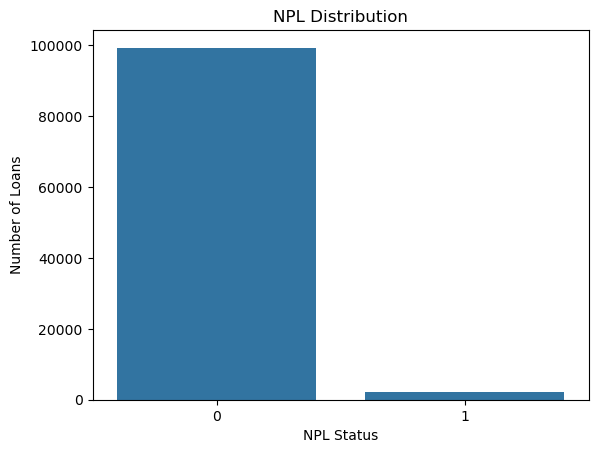

In [22]:
sns.countplot(x="NPL", data=df)

plt.title("NPL Distribution")
plt.xlabel("NPL Status")
plt.ylabel("Number of Loans")

plt.show()

In [23]:
pd.crosstab(
    df["LOANTYPE"],
    df["NPL"],
    normalize="index"
) * 100

NPL,0,1
LOANTYPE,,
Omnipay MFC,92.255892,7.744108
bnpl,97.166842,2.833158
bullet,98.275862,1.724138
cg,99.665831,0.334169
multiproNew,99.639789,0.360211
newbnpl,97.315436,2.684564
paylaterPlus,99.698582,0.301418


In [24]:
# Analyze NPL by loan type
# NPL risk varies significantly across loan types and geographic markets.
npl_by_type = (
    df.groupby("LOANTYPE")["NPL"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(npl_by_type)

LOANTYPE
Omnipay MFC     7.744108
bnpl            2.833158
newbnpl         2.684564
bullet          1.724138
multiproNew     0.360211
cg              0.334169
paylaterPlus    0.301418
Name: NPL, dtype: float64


In [25]:
#Analyze NPL by state
#NPL risk varies significantly across loan types and geographic markets.
npl_by_state = (
    df.groupby("State Name")["NPL"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(npl_by_state.head(20))

State Name
Abuja                 9.120521
Bauchi                5.882353
Oyo                   5.372314
Kwara                 4.166667
Ogun                  3.567182
Lagos                 2.479622
Rivers                2.429882
Cross River           2.319236
Nasarawa              2.049530
Kogi                  2.013423
Kano                  1.278409
Abuja Fed. Capital    1.067014
Bayelsa               0.798838
Edo                   0.779727
Osun                  0.709220
Benue                 0.683891
Akwa Ibom             0.582666
Imo                   0.531171
Kaduna                0.520833
Enugu                 0.315742
Name: NPL, dtype: float64


In [26]:
df["Loan_Amount_Band"] = pd.cut(
    df["LOANAMOUNT"],
    bins=[
        0,
        1_000_000,
        5_000_000,
        10_000_000,
        50_000_000,
        np.inf
    ],
    labels=[
        "<1M",
        "1M-5M",
        "5M-10M",
        "10M-50M",
        "50M+"
    ]
)

In [27]:
df.groupby("Loan_Amount_Band")["NPL"].mean() * 100

Loan_Amount_Band
<1M        4.507382
1M-5M      2.041315
5M-10M     1.303964
10M-50M    0.971813
50M+       0.810373
Name: NPL, dtype: float64

In [28]:
#Prepare X and y
X = df.drop(
    columns=features_to_drop + ["NPL"],
    errors="ignore"
)

y = df["NPL"]

In [29]:
#We then identify numeric and categorical variables
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

In [30]:
#Handle missing values
#For numerical columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [31]:
#Handle missing values
#For categorical columns

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [32]:
# Then combine them
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [33]:
#Split the data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [34]:
# Why stratify=y?

#Because NPL is rare.

#We want approximately the same proportion of NPL loans in the training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [35]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [36]:
logistic_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

In [38]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.90      0.95     19855
           1       0.16      0.93      0.27       414

    accuracy                           0.90     20269
   macro avg       0.58      0.92      0.61     20269
weighted avg       0.98      0.90      0.93     20269



In [39]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_probability
    )
)

ROC-AUC: 0.9661321756648747


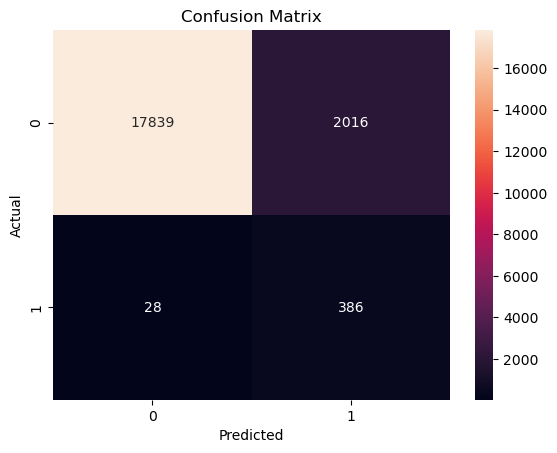

In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [41]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

In [42]:
random_forest_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
rf_pred = random_forest_model.predict(X_test)

rf_probability = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [44]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_probability
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     19855
           1       0.89      0.66      0.76       414

    accuracy                           0.99     20269
   macro avg       0.94      0.83      0.88     20269
weighted avg       0.99      0.99      0.99     20269

ROC-AUC: 0.9920181582171224


In [45]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 1. Generate predictions for Logistic Regression
# (Replace 'log_reg_model' with your actual trained Logistic Regression variable)
y_pred_lr = logistic_model.predict(X_test)
y_proba_lr = logistic_model.predict_proba(X_test)[:, 1]

# 2. Generate predictions for Random Forest
# (Replace 'rf_model' with your actual trained Random Forest variable)
y_pred_rf = random_forest_model.predict(X_test)
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# 3. Calculate metrics
metrics_data = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf)
    ]
}

# 4. Create and display the DataFrame
comparison_df = pd.DataFrame(metrics_data)
# Optional: Round the numbers to 4 decimal places for clean formatting
print(comparison_df.round(4).to_string(index=False))


              Model  Precision  Recall     F1  ROC-AUC
Logistic Regression     0.1607  0.9324 0.2741   0.9661
      Random Forest     0.8922  0.6594 0.7583   0.9920


In [46]:
#Generate an actual risk score - Step 1
risk_probability = random_forest_model.predict_proba(X)[:, 1]

In [47]:
#Generate an actual risk score - Step 2
df["NPL_Probability"] = risk_probability

In [48]:
#Generate an actual risk score - Step 3
df["Risk_Category"] = pd.cut(
    df["NPL_Probability"],
    bins=[0, 0.30, 0.60, 1],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

#Now your data can look like:
# | Loan | NPL Probability | Risk   |
# | ---- | --------------: | ------ |
# | A    |            0.08 | Low    |
# | B    |            0.47 | Medium |
# | C    |            0.83 | High   |


In [49]:
# ============================================================
# STEP 27 — GENERATE NPL PREDICTIONS FOR 100% OF THE DATA
# ============================================================

# ------------------------------------------------------------
# 1. Recreate the complete feature dataset
# ------------------------------------------------------------

X_all = df.drop(
    columns=features_to_drop + ["NPL"],
    errors="ignore"
)

print("Original dataset:", len(df))
print("Records going into prediction:", len(X_all))


# ------------------------------------------------------------
# 2. Make sure X_all has EXACTLY the same features used
#    when the Random Forest model was trained
# ------------------------------------------------------------

X_all = X_all[X_train.columns]

print("Number of features:", X_all.shape[1])


# ------------------------------------------------------------
# 3. Generate predictions for ALL records
# ------------------------------------------------------------

all_pred = random_forest_model.predict(X_all)

all_probability = random_forest_model.predict_proba(X_all)[:, 1]


# ------------------------------------------------------------
# 4. Confirm predictions were generated for every row
# ------------------------------------------------------------

print()
print("Number of predictions:", len(all_pred))
print("Number of probabilities:", len(all_probability))
print("Number of original records:", len(df))


# ------------------------------------------------------------
# 5. Create the final dataset using the ORIGINAL data
# ------------------------------------------------------------

final_data = df[
    [
        "REF",
        "Name",
        "Phone",
        "Address",
        "LOANID",
        "ORDERID",
        "ORDERSOURCE",
        "State Name",
        "LOANDATE",
        "LOANAMOUNT",
        "LOANTYPE",
        "Agent Name",
        "TeamLead",
        "LENDERNAME",
        "Organisation_Name",
        "Loan Status",
        "Loan Aging",
        "Loan Aging Bucket"
    ]
].copy()


# ------------------------------------------------------------
# 6. Add actual NPL status
# ------------------------------------------------------------

final_data["Actual_NPL"] = df["NPL"].values


# ------------------------------------------------------------
# 7. Add prediction for EVERY row
# ------------------------------------------------------------

final_data["Predicted_NPL"] = all_pred


# ------------------------------------------------------------
# 8. Add NPL probability for EVERY row
# ------------------------------------------------------------

final_data["NPL_Probability"] = all_probability


# ------------------------------------------------------------
# 9. Create Risk Level for EVERY row
# ------------------------------------------------------------

final_data["Risk_Level"] = np.where(
    final_data["NPL_Probability"] >= 0.70,
    "High Risk",
    np.where(
        final_data["NPL_Probability"] >= 0.40,
        "Medium Risk",
        "Low Risk"
    )
)


# ------------------------------------------------------------
# 10. Export the complete 100% dataset
# ------------------------------------------------------------

output_path = (
    r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI"
    r"\Real World Gen AI Projects\Loan_NPL_Prediction"
    r"\notebooks\npl_risk_dashboard_100_percent.csv"
)

final_data.to_csv(
    output_path,
    index=False
)


# ============================================================
# 11. VERIFY THE EXPORT
# ============================================================

print()
print("=" * 60)
print("100% NPL PREDICTION EXPORT COMPLETED")
print("=" * 60)

print()
print("Original records:", len(df))
print("Final export records:", len(final_data))
print("Predictions generated:", len(all_pred))
print("Risk levels generated:", final_data["Risk_Level"].notna().sum())

print()
print("Risk Level Distribution:")
print(final_data["Risk_Level"].value_counts())

print()
print("Predicted NPL Distribution:")
print(final_data["Predicted_NPL"].value_counts())

print()
print("Missing Predictions:")
print(final_data["Predicted_NPL"].isna().sum())

print()
print("Missing NPL Probabilities:")
print(final_data["NPL_Probability"].isna().sum())

print()
print("Missing Risk Levels:")
print(final_data["Risk_Level"].isna().sum())

print()
print("Final dataset shape:")
print(final_data.shape)

print()
print("File saved to:")
print(output_path)

Original dataset: 101343
Records going into prediction: 101343
Number of features: 23

Number of predictions: 101343
Number of probabilities: 101343
Number of original records: 101343

100% NPL PREDICTION EXPORT COMPLETED

Original records: 101343
Final export records: 101343
Predictions generated: 101343
Risk levels generated: 101343

Risk Level Distribution:
Risk_Level
Low Risk       99332
High Risk       1683
Medium Risk      328
Name: count, dtype: int64

Predicted NPL Distribution:
Predicted_NPL
0    99376
1     1967
Name: count, dtype: int64

Missing Predictions:
0

Missing NPL Probabilities:
0

Missing Risk Levels:
0

Final dataset shape:
(101343, 22)

File saved to:
C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\notebooks\npl_risk_dashboard_100_percent.csv


In [51]:
# STEP 29A — CHECK ACTUAL COLUMNS IN FINAL CSV

import pandas as pd

final_path = r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\notebooks\npl_risk_dashboard_100_percent.csv"

final_df = pd.read_csv(final_path)

print("========== FINAL CSV INSPECTION ==========")

print("Number of rows:", len(final_df))
print("Number of columns:", len(final_df.columns))

print("\n========== COLUMN NAMES ==========")

for i, col in enumerate(final_df.columns, start=1):
    print(f"{i}. {col}")

print("\n========== FIRST 5 ROWS ==========")

display(final_df.head())

========== FINAL CSV INSPECTION ==========
Number of rows: 101343
Number of columns: 22

========== COLUMN NAMES ==========
1. REF
2. Name
3. Phone
4. Address
5. LOANID
6. ORDERID
7. ORDERSOURCE
8. State Name
9. LOANDATE
10. LOANAMOUNT
11. LOANTYPE
12. Agent Name
13. TeamLead
14. LENDERNAME
15. Organisation_Name
16. Loan Status
17. Loan Aging
18. Loan Aging Bucket
19. Actual_NPL
20. Predicted_NPL
21. NPL_Probability
22. Risk_Level

========== FIRST 5 ROWS ==========


,REF,Name,Phone,Address,LOANID,ORDERID,ORDERSOURCE,State Name,LOANDATE,LOANAMOUNT,...,TeamLead,LENDERNAME,Organisation_Name,Loan Status,Loan Aging,Loan Aging Bucket,Actual_NPL,Predicted_NPL,NPL_Probability,Risk_Level
0,0ehu7bhxb,Hannah Amiesimaka,08033398479,"118, Bende street, Borokiri, Town, Port Harcou...",c0wisbb8li,97386161,Distributor App,Rivers,2026-09-08 00:59:38,15400000.0,...,Bright Ezenwa Agoha,OmniPay Limited,VHANESKA NIG ENTERPRISES,Zero Repayment,1 Days,1-3 Days,0,0,0.000000,Low Risk
1,6vgh6l8ki,ONU CHRISTIAN EMEKA,08030763935,"772, behind KP plaza Kapwa FLT 8 lugbe , Abuja",wahx6p3xvr,173416554,NaN,Abuja Fed. Capital,2026-09-08 00:49:22,2064000.0,...,Olorunfemi Temidayo,OmniPay Limited,ONU CHRISTIAN EMEKA,Zero Repayment,1 Days,1-3 Days,0,0,0.000000,Low Risk
2,16azbpz86,Omidiora Ebenezer S,08032082889,2 onabadejo cls ipaja,7zth0jui8k,173416553,NaN,Lagos,2026-09-08 00:47:41,500000.0,...,Ogungbola Abdulwasiu Abdulazeez,OmniPay Limited,Omidiora Ebenezer S,Zero Repayment,1 Days,1-3 Days,0,0,0.006667,Low Risk
3,2aiditrq4,Ndubisi Robinson,08069793488,"15/12, JOHN OGUN MUYIWA STREET OFF SHOSANYA IJ...",2fpc3yqzji,DMS_106914,NaN,Lagos,2026-09-08 00:46:20,2639000.0,...,Olagunju Olanrewaju,OmniPay Limited,Ndubisi Robinson,Zero Repayment,1 Days,1-3 Days,0,0,0.000000,Low Risk
4,czr1eb245,Okpara christopher onyegbule,08020556167,33b Alebiosun Street ijegun satellite ojo,cb0kkxxi9k,DMS_106913,NaN,Lagos,2026-09-08 00:28:57,1040714.0,...,Udofia Wisdom,OmniPay Limited,Okpara christopher onyegbule,Zero Repayment,1 Days,1-3 Days,0,0,0.000000,Low Risk


In [52]:
# STEP 30A — CHECK PREDICTION COLUMN

print("Predicted_NPL values:")
print(final_df["Predicted_NPL"].value_counts(dropna=False))

print("\nMissing Predicted_NPL:")
print(final_df["Predicted_NPL"].isna().sum())

print("\nAll columns:")
print(final_df.columns.tolist())

Predicted_NPL values:
Predicted_NPL
0    99376
1     1967
Name: count, dtype: int64

Missing Predicted_NPL:
0

All columns:
['REF', 'Name', 'Phone', 'Address', 'LOANID', 'ORDERID', 'ORDERSOURCE', 'State Name', 'LOANDATE', 'LOANAMOUNT', 'LOANTYPE', 'Agent Name', 'TeamLead', 'LENDERNAME', 'Organisation_Name', 'Loan Status', 'Loan Aging', 'Loan Aging Bucket', 'Actual_NPL', 'Predicted_NPL', 'NPL_Probability', 'Risk_Level']


In [53]:
# STEP 30B — LOOK FOR PROBABILITY COLUMNS

for col in final_df.columns:
    if "prob" in col.lower() or "score" in col.lower():
        print(col)

NPL_Probability


In [56]:
# STEP 30C — CREATE RISK LEVEL

def assign_risk(probability):
    
    if probability < 0.30:
        return "Low"
    
    elif probability < 0.70:
        return "Medium"
    
    else:
        return "High"


# Create Risk Level for every row
final_df["Risk_Level"] = final_df["NPL_Probability"].apply(assign_risk)

# Check the result
print("========== RISK LEVEL DISTRIBUTION ==========")
print(final_df["Risk_Level"].value_counts(dropna=False))

========== RISK LEVEL DISTRIBUTION ==========
Risk_Level
Low       99266
High       1683
Medium      394
Name: count, dtype: int64


In [57]:
# STEP 30D — CHECK FOR MISSING RISK LEVELS

missing_risk = final_df["Risk_Level"].isna().sum()

print("Total rows:", len(final_df))
print("Missing Risk_Level:", missing_risk)

if missing_risk == 0:
    print("✅ SUCCESS: Every row has a Risk Level.")
else:
    print("❌ WARNING: Some rows are missing Risk Level.")

Total rows: 101343
Missing Risk_Level: 0
✅ SUCCESS: Every row has a Risk Level.


In [58]:
# STEP 30E — VIEW INDIVIDUAL LOAN RISK LEVELS

display(
    final_df[
        ["Predicted_NPL", "NPL_Probability", "Risk_Level"]
    ].head(20)
)

,Predicted_NPL,NPL_Probability,Risk_Level
0,0,0.000000,Low
1,0,0.000000,Low
2,0,0.006667,Low
3,0,0.000000,Low
4,0,0.000000,Low
5,0,0.013333,Low
6,0,0.010000,Low
7,0,0.003333,Low
8,0,0.010000,Low
9,0,0.003333,Low


In [59]:
# STEP 30F — SAVE FINAL DATASET WITH RISK LEVEL

output_path = r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\notebooks\npl_risk_dashboard_100_percent.csv"

final_df.to_csv(output_path, index=False)

print("✅ Final CSV saved successfully.")
print("Location:")
print(output_path)

✅ Final CSV saved successfully.
Location:
C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\notebooks\npl_risk_dashboard_100_percent.csv


In [60]:
print(final_df["Risk_Level"].value_counts(dropna=False))

Risk_Level
Low       99266
High       1683
Medium      394
Name: count, dtype: int64


In [61]:
print("Total rows:", len(final_df))
print("Missing Risk_Level:", final_df["Risk_Level"].isna().sum())

Total rows: 101343
Missing Risk_Level: 0


In [62]:
# ============================================================
# STEP 31 — FINAL 100% DATASET VALIDATION
# ============================================================

import pandas as pd

# Load original dataset
original_df = pd.read_excel(
    r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\data\Loan Information_Data.xlsx"
)

# Load final prediction dataset
final_df = pd.read_csv(
    r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\notebooks\npl_risk_dashboard_100_percent.csv"
)

print("=" * 60)
print("STEP 31 — FINAL 100% DATASET VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. ROW COUNT
# ------------------------------------------------------------

print("\n1. ROW COUNT")
print("-" * 40)

print("Original dataset rows:", len(original_df))
print("Final dataset rows:", len(final_df))

if len(original_df) == len(final_df):
    print("✅ PASS — Final dataset contains 100% of original rows.")
else:
    print("❌ FAIL — Row counts do not match.")
    print("Difference:", len(original_df) - len(final_df))


# ------------------------------------------------------------
# 2. REQUIRED COLUMNS
# ------------------------------------------------------------

print("\n2. REQUIRED PREDICTION COLUMNS")
print("-" * 40)

required_columns = [
    "Predicted_NPL",
    "NPL_Probability",
    "Risk_Level"
]

for col in required_columns:
    if col in final_df.columns:
        print(f"✅ {col} exists")
    else:
        print(f"❌ {col} is missing")


# ------------------------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------------------------

print("\n3. MISSING VALUES")
print("-" * 40)

for col in required_columns:
    if col in final_df.columns:
        missing = final_df[col].isna().sum()
        print(f"{col}: {missing}")


# ------------------------------------------------------------
# 4. RISK LEVEL DISTRIBUTION
# ------------------------------------------------------------

print("\n4. RISK LEVEL DISTRIBUTION")
print("-" * 40)

print(final_df["Risk_Level"].value_counts(dropna=False))


# ------------------------------------------------------------
# 5. PREDICTED NPL DISTRIBUTION
# ------------------------------------------------------------

print("\n5. PREDICTED NPL DISTRIBUTION")
print("-" * 40)

print(final_df["Predicted_NPL"].value_counts(dropna=False))


# ------------------------------------------------------------
# 6. PROBABILITY RANGE
# ------------------------------------------------------------

print("\n6. NPL PROBABILITY RANGE")
print("-" * 40)

print("Minimum probability:", final_df["NPL_Probability"].min())
print("Maximum probability:", final_df["NPL_Probability"].max())


# ------------------------------------------------------------
# 7. DUPLICATE ROWS
# ------------------------------------------------------------

print("\n7. DUPLICATE ROWS")
print("-" * 40)

duplicates = final_df.duplicated().sum()

print("Duplicate rows:", duplicates)

if duplicates == 0:
    print("✅ PASS — No duplicate rows.")
else:
    print("⚠️ WARNING — Duplicate rows found.")


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL VALIDATION COMPLETE")
print("=" * 60)

STEP 31 — FINAL 100% DATASET VALIDATION

1. ROW COUNT
----------------------------------------
Original dataset rows: 101343
Final dataset rows: 101343
✅ PASS — Final dataset contains 100% of original rows.

2. REQUIRED PREDICTION COLUMNS
----------------------------------------
✅ Predicted_NPL exists
✅ NPL_Probability exists
✅ Risk_Level exists

3. MISSING VALUES
----------------------------------------
Predicted_NPL: 0
NPL_Probability: 0
Risk_Level: 0

4. RISK LEVEL DISTRIBUTION
----------------------------------------
Risk_Level
Low       99266
High       1683
Medium      394
Name: count, dtype: int64

5. PREDICTED NPL DISTRIBUTION
----------------------------------------
Predicted_NPL
0    99376
1     1967
Name: count, dtype: int64

6. NPL PROBABILITY RANGE
----------------------------------------
Minimum probability: 0.0
Maximum probability: 1.0

7. DUPLICATE ROWS
----------------------------------------
Duplicate rows: 0
✅ PASS — No duplicate rows.

FINAL VALIDATION COMPLETE


In [65]:
import os

project_path = r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction"

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Loan_NPL_Prediction/
    dashboard/
        NPL_risk_dashboard.pbix
    data/
        Loan Information_Data.xlsx
    Junk Files/
        My_NPL_Jupyter_Notebook_Code_Text_Format.txt
        npl_risk_dashboard - Copy (2).csv
        npl_risk_dashboard - Copy.csv
        Questions to ask to turn the power dashboard into the dashboard into business conclusions..txt
        Steps.txt
    models/
    notebooks/
        loan_npl_prediction.ipynb
        npl_risk_dashboard.csv
        npl_risk_dashboard_100_percent.csv
    outputs/
        npl_risk_dashboard_100_percent.csv


In [66]:
import pickle

model_path = r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\models\random_forest_npl_model.pkl"

with open(model_path, "wb") as file:
    pickle.dump(random_forest_model, file)

print("Random Forest model saved successfully!")
print(model_path)

Random Forest model saved successfully!
C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\models\random_forest_npl_model.pkl


In [67]:
import pickle
import pandas as pd

# ------------------------------------------------------------
# LOAD SAVED RANDOM FOREST MODEL
# ------------------------------------------------------------

model_path = r"C:\Users\Ule Chinyere\Videos\Data Science\Generative AI\Real World Gen AI Projects\Loan_NPL_Prediction\models\random_forest_npl_model.pkl"

with open(model_path, "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [68]:
# ------------------------------------------------------------
# TEST SAVED MODEL
# ------------------------------------------------------------

# Take one record from the existing test dataset
sample = X_test.iloc[[0]]

# Generate prediction
test_prediction = loaded_model.predict(sample)

# Generate NPL probability
test_probability = loaded_model.predict_proba(sample)[:, 1]

print("Predicted NPL:", test_prediction[0])
print("NPL Probability:", test_probability[0])

Predicted NPL: 0
NPL Probability: 0.0


In [69]:
# ------------------------------------------------------------
# TEST RISK LEVEL
# ------------------------------------------------------------

probability = test_probability[0]

if probability < 0.30:
    risk_level = "Low"
elif probability < 0.70:
    risk_level = "Medium"
else:
    risk_level = "High"

print("Predicted NPL:", test_prediction[0])
print("NPL Probability:", probability)
print("Risk Level:", risk_level)

Predicted NPL: 0
NPL Probability: 0.0
Risk Level: Low
